In [1]:
!pip install nltk textblob

In [2]:
import pandas as pd
import nltk
import string
from textblob import TextBlob
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
reviews = [
    "The food was delicious and delivery was fast.",
    "Very bad service. Food was cold.",
    "Excellent taste and good packaging.",
    "Delivery was too late and food was stale.",
    "Loved the pizza. Highly recommended.",
    "Poor customer service and expensive food.",
    "Amazing burger and quick delivery.",
    "Packaging was damaged.",
    "Food quality is excellent.",
    "The staff was friendly and helpful.",
    "Waiting time was very long.",
    "Food was tasty but delivery was slow.",
    "Affordable price and delicious food.",
    "The order was incorrect.",
    "Very satisfied with the service."
]

df = pd.DataFrame(reviews, columns=["Review"])

df.head()

,Review
0,The food was delicious and delivery was fast.
1,Very bad service. Food was cold.
2,Excellent taste and good packaging.
3,Delivery was too late and food was stale.
4,Loved the pizza. Highly recommended.


In [5]:
nltk.download('punkt_tab')

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned_Review"] = df["Review"].apply(clean_text)

df.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,Review,Cleaned_Review
0,The food was delicious and delivery was fast.,food delicious delivery fast
1,Very bad service. Food was cold.,bad service food cold
2,Excellent taste and good packaging.,excellent taste good packaging
3,Delivery was too late and food was stale.,delivery late food stale
4,Loved the pizza. Highly recommended.,loved pizza highly recommended


In [6]:
def sentiment(text):

    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned_Review"].apply(sentiment)

df

,Review,Cleaned_Review,Sentiment
0,The food was delicious and delivery was fast.,food delicious delivery fast,Positive
1,Very bad service. Food was cold.,bad service food cold,Negative
2,Excellent taste and good packaging.,excellent taste good packaging,Positive
3,Delivery was too late and food was stale.,delivery late food stale,Negative
4,Loved the pizza. Highly recommended.,loved pizza highly recommended,Positive
5,Poor customer service and expensive food.,poor customer service expensive food,Negative
6,Amazing burger and quick delivery.,amazing burger quick delivery,Positive
7,Packaging was damaged.,packaging damaged,Neutral
8,Food quality is excellent.,food quality excellent,Positive
9,The staff was friendly and helpful.,staff friendly helpful,Positive


In [7]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    8
Negative    5
Neutral     2
Name: count, dtype: int64


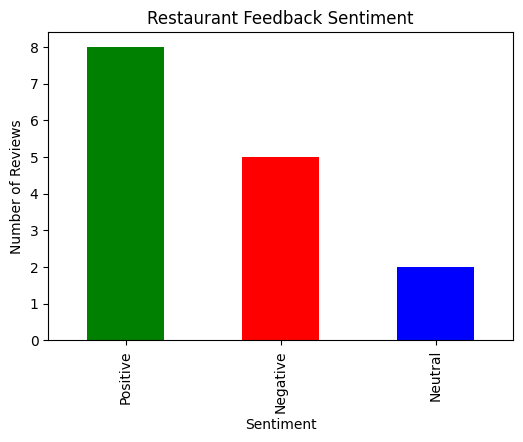

In [8]:
df["Sentiment"].value_counts().plot(
    kind="bar",
    color=["green","red","blue"],
    figsize=(6,4)
)

plt.title("Restaurant Feedback Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [9]:
issues = [
    "late",
    "slow",
    "cold",
    "stale",
    "damaged",
    "expensive",
    "incorrect",
    "waiting",
    "poor"
]

issue_count = {}

for issue in issues:
    count = df["Cleaned_Review"].str.contains(issue).sum()
    issue_count[issue] = count

issue_df = pd.DataFrame(issue_count.items(), columns=["Issue","Count"])

print(issue_df)

       Issue  Count
0       late      1
1       slow      1
2       cold      1
3      stale      1
4    damaged      1
5  expensive      1
6  incorrect      1
7    waiting      1
8       poor      1


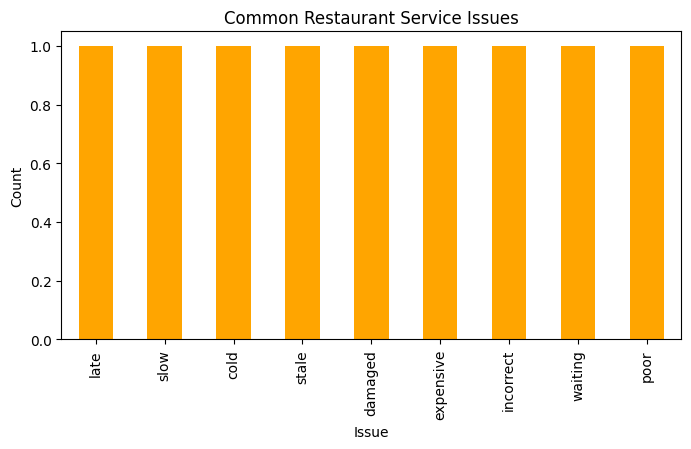

In [10]:
issue_df.plot(
    x="Issue",
    y="Count",
    kind="bar",
    legend=False,
    figsize=(8,4),
    color="orange"
)

plt.title("Common Restaurant Service Issues")
plt.ylabel("Count")
plt.show()

In [11]:
print("========== FEEDBACK ANALYSIS REPORT ==========")

print("\nTotal Reviews :", len(df))

print("\nSentiment Summary:")
print(df["Sentiment"].value_counts())

print("\nCommon Issues:")
print(issue_df.sort_values(by="Count", ascending=False))

print("\nOverall Analysis:")

positive = (df["Sentiment"]=="Positive").sum()
negative = (df["Sentiment"]=="Negative").sum()

if positive > negative:
    print("Customer satisfaction is GOOD.")
else:
    print("Restaurant needs improvement.")

========== FEEDBACK ANALYSIS REPORT ==========

Total Reviews : 15

Sentiment Summary:
Sentiment
Positive    8
Negative    5
Neutral     2
Name: count, dtype: int64

Common Issues:
       Issue  Count
0       late      1
1       slow      1
2       cold      1
3      stale      1
4    damaged      1
5  expensive      1
6  incorrect      1
7    waiting      1
8       poor      1

Overall Analysis:
Customer satisfaction is GOOD.
